**Project Title : House Price Prediction**

**Project:** Week 1 Project : Predict house prices from property features and identify the strongest price drivers.

Dataset : [Housing.csv](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
print("Rows, Columns:", df.shape)

Rows, Columns: (545, 13)


**Target column:** `price`
**Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`

In [3]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing values in any column — the dataset is clean as-is.

## Task 2 — Data Cleaning

Steps:
1. Handle missing values (none found, but the code below is defensive in case new data is added later)
2. Remove duplicate rows
3. One-hot encode categorical (yes/no and furnishing) columns
4. Keep all columns — every feature here is plausibly predictive of price

In [ ]:
# 1. Handle missing values (fill or drop, whichever fits the column)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 2. Remove duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Duplicate rows removed: {before - df.shape[0]}")

Duplicate rows removed: 0


In [ ]:
# 3. Encode binary yes/no columns as 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [6]:
print("Shape after cleaning & encoding:", df.shape)
df.dtypes

Shape after cleaning & encoding: (545, 14)


price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

## Task 3 — Model Building

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 436  Test size: 109


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression -> MAE: {lr_mae:,.0f}  RMSE: {lr_rmse:,.0f}  R²: {lr_r2:.3f}")

Linear Regression -> MAE: 970,043  RMSE: 1,324,507  R²: 0.653


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest  ->  MAE: {rf_mae:,.0f}  RMSE: {rf_rmse:,.0f}  R²: {rf_r2:.3f}")

Random Forest  ->  MAE: 1,014,947  RMSE: 1,399,769  R²: 0.612


In [17]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


On this particular dataset, **Linear Regression slightly outperforms Random Forest** (high R² score, low error).
It is important to remember that not all complex models are necessarily good – in the case of the given dataset, 
with only ~545 entries, Random Forest does not have sufficient amount of data to discover any patterns beyond linear ones.

## Task 4 — Visualization

### Chart 1: Distribution of House Prices

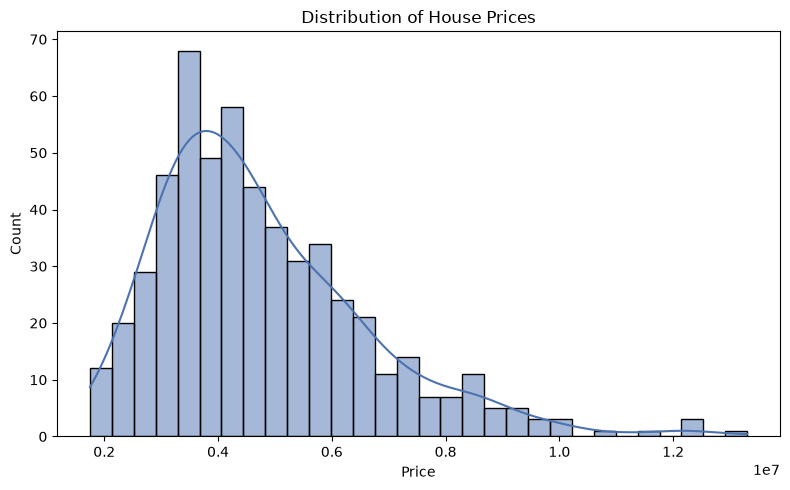

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Chart 2: Correlation Heatmap

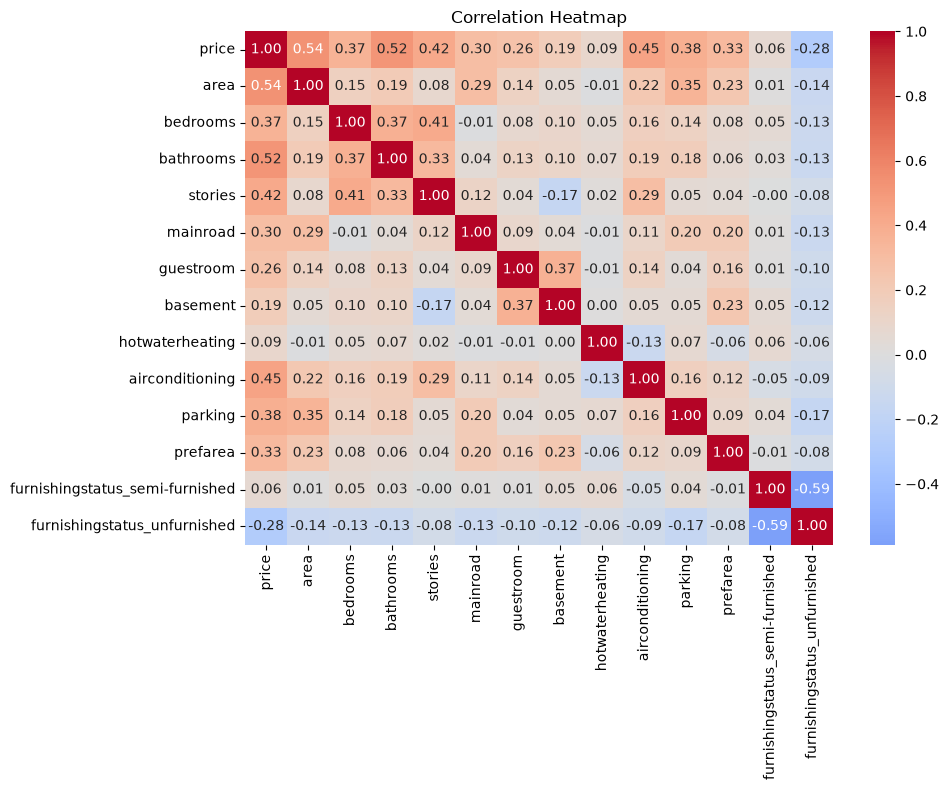

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Chart 3: Actual vs. Predicted Price (Linear Regression — the better-performing model)

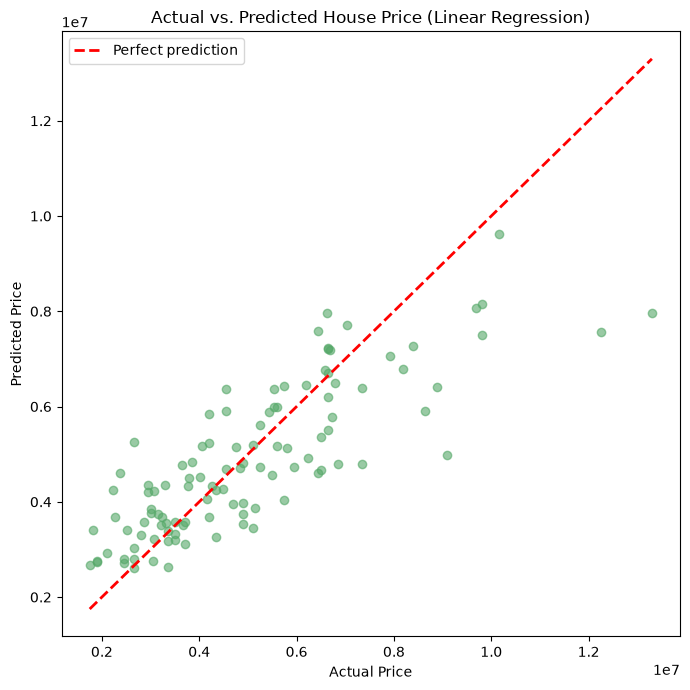

In [13]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, lr_pred, alpha=0.6, color="#55A868")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Price (Linear Regression)")
plt.legend()
plt.tight_layout()
plt.show()

## Task 5 — Insights & Summary

In [14]:
correlations = df.corr()['price'].drop('price').sort_values(ascending=False)
correlations

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

**Which features influence price most?**

`area` and `bathrooms` are the strongest drivers — area alone has the highest correlation with price (~0.54), 
and Random Forest's feature-importance ranking agrees, putting area far ahead of everything else. 
`airconditioning`, `stories`, and `parking` also matter meaningfully, while `hotwaterheating` and `furnishing status` 
have only a small effect.

**How accurate was the model(in plain terms)?**

The Linear Regression model explains about 65% of the variation in house prices (R² ≈ 0.65), with a typical 
prediction error of roughly ₹970,000 — useful for a rough estimate, but not precise enough to set a final 
listing price on its own. Buyers should treat its output as a starting point for negotiation, not a final number.

**What surprised you in the data ?**

Random Forest, despite being a more flexible model, did *not* beat plain Linear Regression here. With only 
~545 rows, the extra complexity Random Forest can model isn't backed by enough data to pay off — a good 
reminder that bigger/fancier models aren't automatically better on small datasets.

**One recommendation for a real estate business based on your findings??**

Since `area` and `bathrooms` dominate price far more than secondary amenities, a real estate business should 
prioritize accurately measuring and prominently advertising square footage and bathroom count in every listing, 
and treat features like hot water heating or furnishing status as minor value-adds rather than core selling points.


